## Purpose of the Interactive Notebook

The `TOAD_Amazon_interactive.ipynb` is an interactive sandbox that allows you to:
- **Select different models and variables** and see results immediately
- **Tune TOAD parameters** (shift detection, clustering) while observing the effects
- **Explore the TOAD pipeline** step-by-step for learning and debugging

### Quick Start Guide

**Step 1: Choose a variable**
```python
MODEL = "GFDL-ESM4" #Data available from CMIP6 GFDL-ESM4 and TaiESM1 for the Analysis of the Amazon Basin Biome 
VARIABLE = "cVeg"  # Options: cVeg, MCWD, fFire, grassFrac, treeFrac, AnnualRainfall
ROLLING_YEARS = 1  # Options: 1 (annual), 5 (5-year smooth), 10 (10-year smooth) based on the variable smoothing - review "config" files for respective model selected
```

**Step 2: Load and explore data**
- Run Cells to load the preprocessed .nc file
- View preprocessing results: trend plot and spatial distribution

**Step 3: Detect shifts**
- Basic method from main TOAD is ASDETECT - no parameter change needed
- Alternative, adjust `window_indices`, `min_abs_change`, `min_rel_change` to tune sensitivity of ASDETECT. Comment out ASDETECT code lines and Uncomment FilteredASDETECT command

**Step 4: Cluster shifts**
- Run Cells for basic clustering with fixed parameters (spatial epsilon, time epsilon, and min_sample)
- Run Cells for optimized clustering. First selected the clustering selection method and then udpate the clustering parameters range. Unlike basic clustering, this method requires a range. One can also edit the number of trials desired for optimization tool. 

In [2]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
import os
from pathlib import Path

# Automatically find Amazon/ directory regardless of where notebook is opened from
current_dir = Path.cwd()
if current_dir.name == "docs":
    amazon_dir = current_dir.parent
else:
    # Search for Amazon directory up the tree
    amazon_dir = current_dir
    while amazon_dir.name != "Amazon" and amazon_dir.parent != amazon_dir:
        amazon_dir = amazon_dir.parent
    if amazon_dir.name != "Amazon":
        amazon_dir = current_dir / ".." / "Amazon"

amazon_dir = amazon_dir.resolve()
print(f"Working from Amazon directory: {amazon_dir}")

# Ensure Amazon directory is in sys.path for imports
if str(amazon_dir) not in sys.path:
    sys.path.insert(0, str(amazon_dir))

Working from Amazon directory: C:\Users\pinto\OneDrive\Documents\Potsdam\Courses\2026 SoSe\ESSA\Project\TOAD_CLEWS\Amazon


### 1. Load Pre-processed Model Data
When the model and variable fields are change, one can see different result automatically!

In [5]:
MODEL = "GFDL-ESM4"
VARIABLE = "grassFrac"
ROLLING_YEARS = 1
# ROLLING_YEARS = 1   # annual for cVeg and grassfrac variable
# ROLLING_YEARS = 5    # 5-year centered rolling mean 
# ROLLING_YEARS = 10   # 10-year centered rolling mean for MCWD, fFire, and treeFrac variables

def smoothing_suffix(rolling_years=None):
    if rolling_years is None or rolling_years <= 1:
        return ""
    return f"_smooth{rolling_years}yr"


def get_plot_path(plot_type, model_name, variable, rolling_years=None):
    suffix = smoothing_suffix(rolling_years)

    filename_map = {
        "trend": f"TrendPlot_{variable}_{model_name}{suffix}.png",
        "spatial": f"SpatialMap_{variable}_{model_name}{suffix}.png",
    }

    return amazon_dir / "plots" / model_name / filename_map[plot_type]

suffix = smoothing_suffix(ROLLING_YEARS)

# Use absolute paths
file_path = amazon_dir / f"processed_data/{MODEL}/TOAD_{VARIABLE}_{MODEL}{suffix}.nc"
print(f"Loading: {file_path}")

Loading: C:\Users\pinto\OneDrive\Documents\Potsdam\Courses\2026 SoSe\ESSA\Project\TOAD_CLEWS\Amazon\processed_data\GFDL-ESM4\TOAD_grassFrac_GFDL-ESM4.nc


In [6]:
# Open the processed dataset(netCDF)
ds = xr.open_dataset(file_path)

#### 1.1 Check Resolution of Model Output

In [7]:
print("source_id:", ds.attrs.get("source_id"))
print("experiment_id:", ds.attrs.get("experiment_id"))
print("variant_label:", ds.attrs.get("variant_label"))
print("First time:", ds["time"].values[0])
print("Last time:", ds["time"].values[-1])
nominal_res = ds.attrs.get("nominal_resolution", "Not Available")
print("Spatial resolution:", f"Nominal Resolution: {nominal_res}")

source_id: GFDL-ESM4
experiment_id: 1pctCO2
variant_label: r1i1p1f1
First time: 0001-01-01 00:00:00
Last time: 0150-01-01 00:00:00
Spatial resolution: Nominal Resolution: 100 km


Annual average, with GWL dataset : `Variable you chose` : (GWL, lat, lon)

this data have annual average of variable in each grid in Amazon area.

#### 1.2 Plot and Check Data

##### (1) Average Trend of Variable in the Amazon region

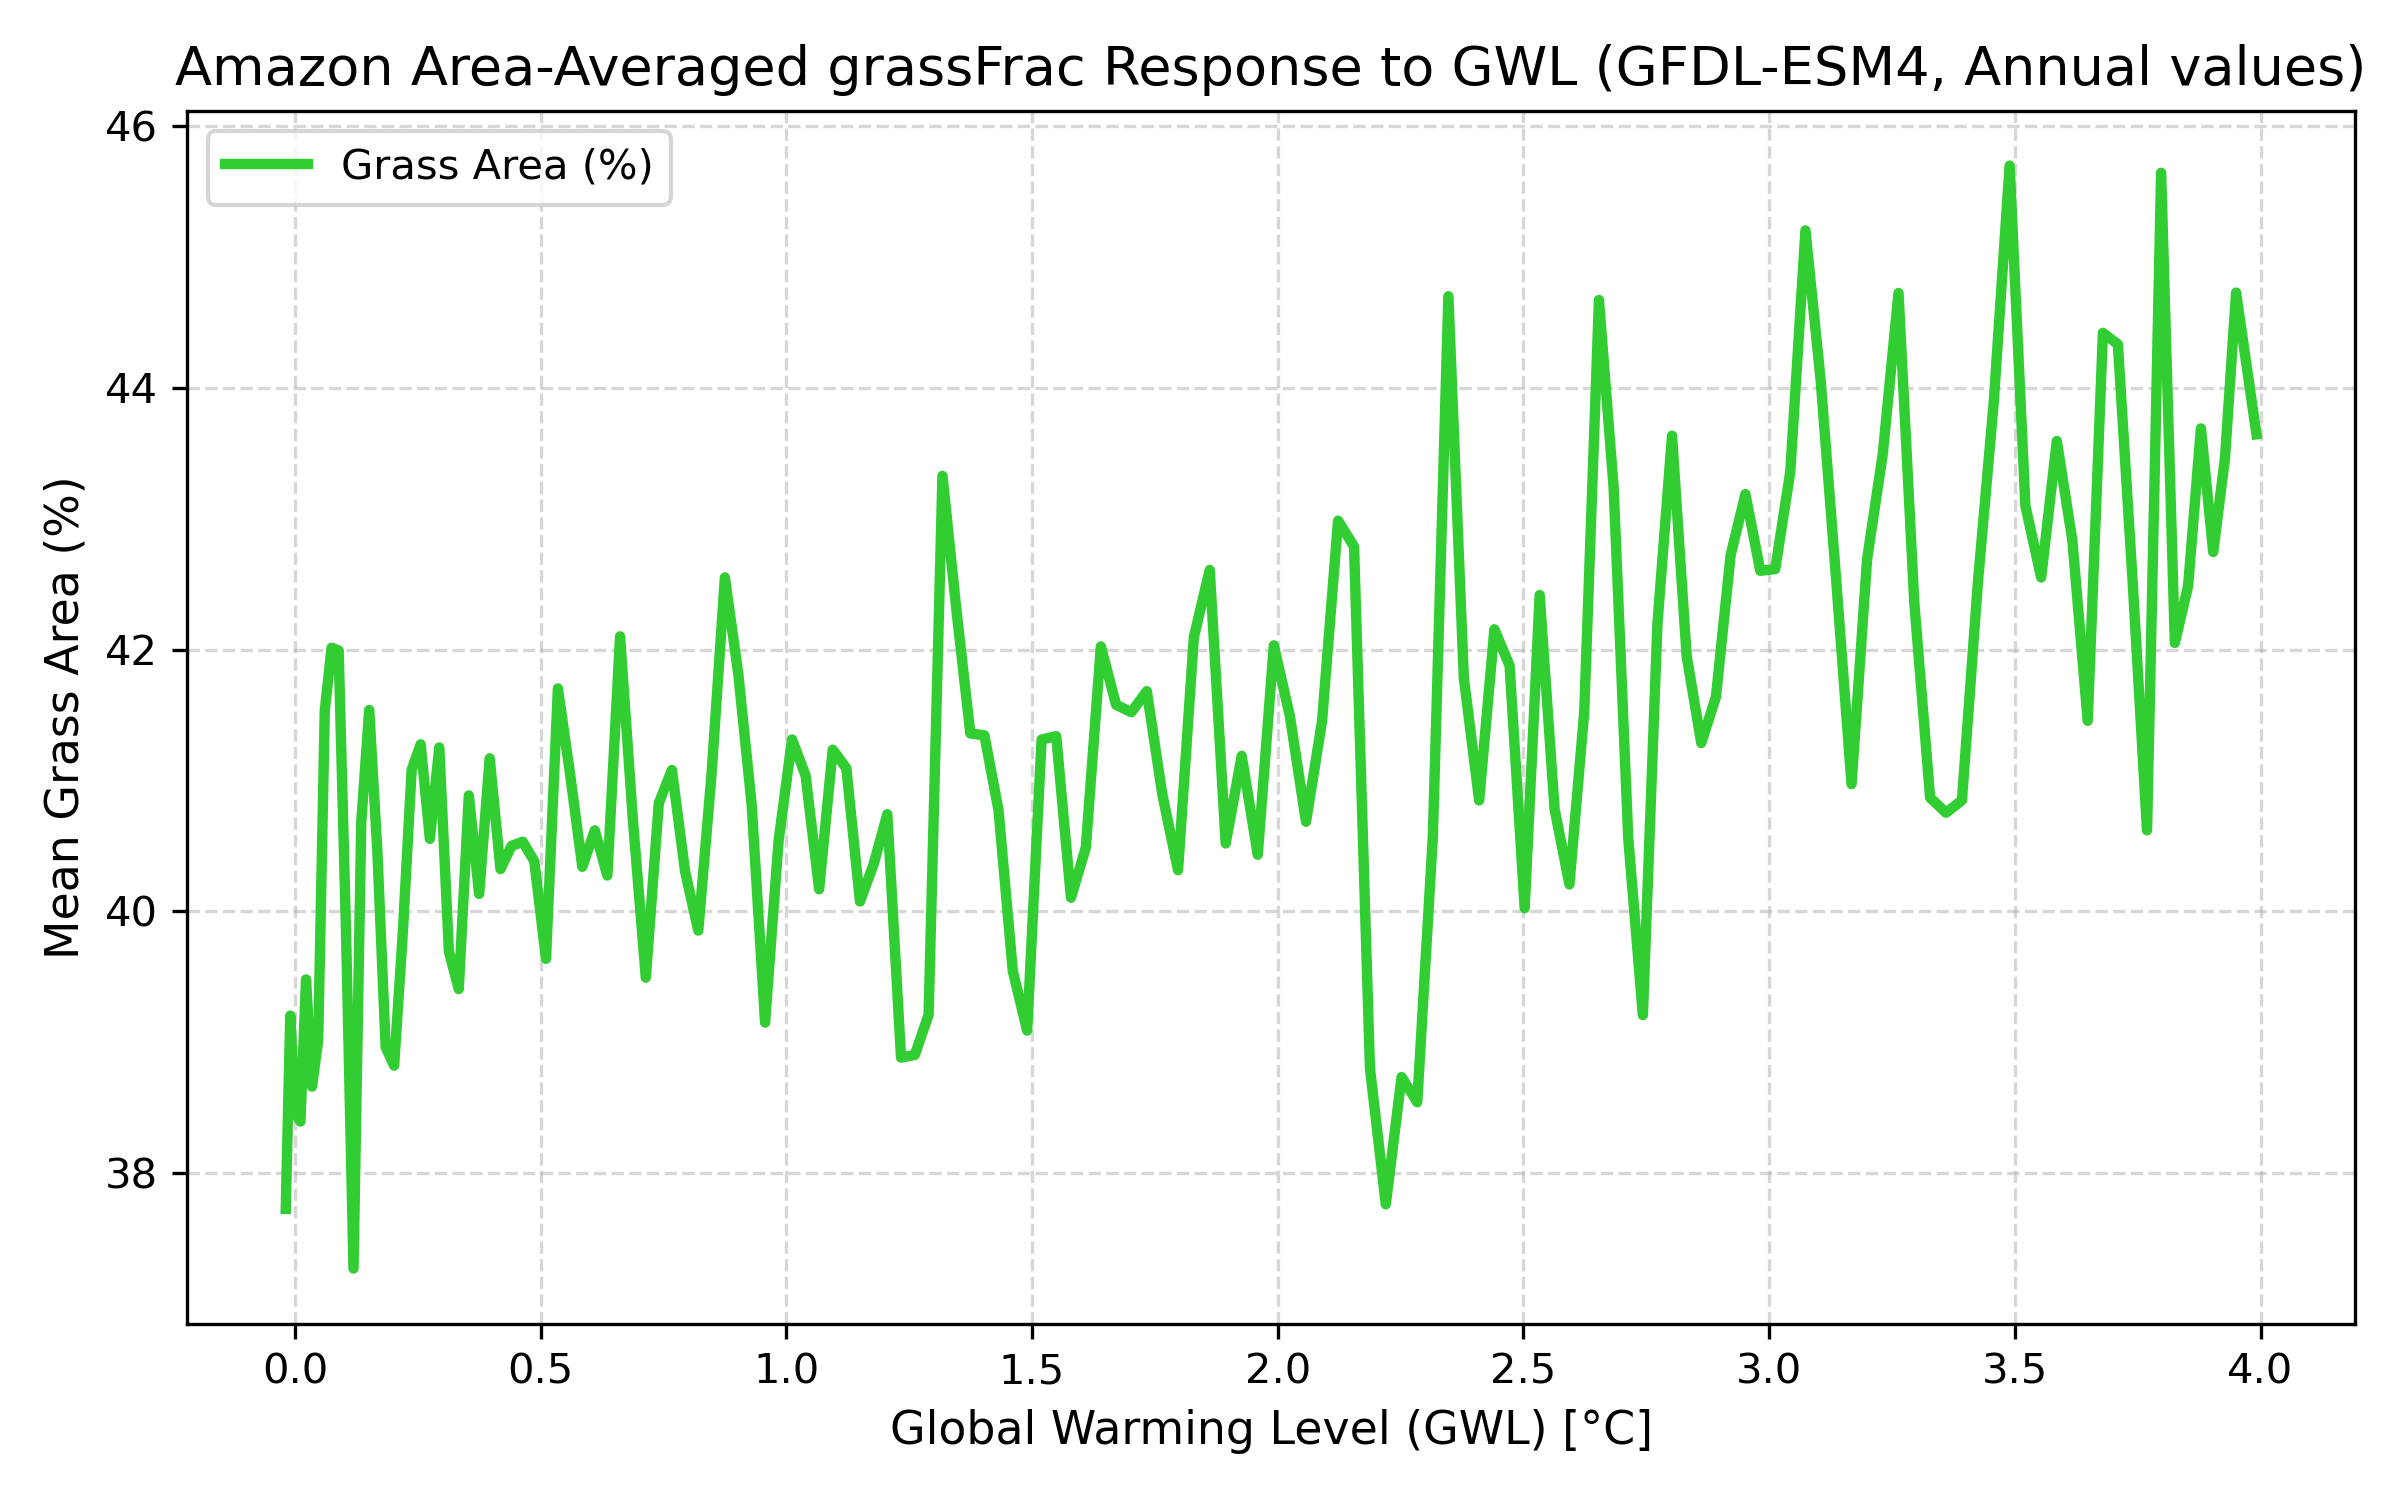

In [8]:
from IPython.display import Image, display

trend_path = amazon_dir / f"plots/{MODEL}/TrendPlot_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(trend_path)))

##### (2) Spatial Distribution by different Global Warming Level

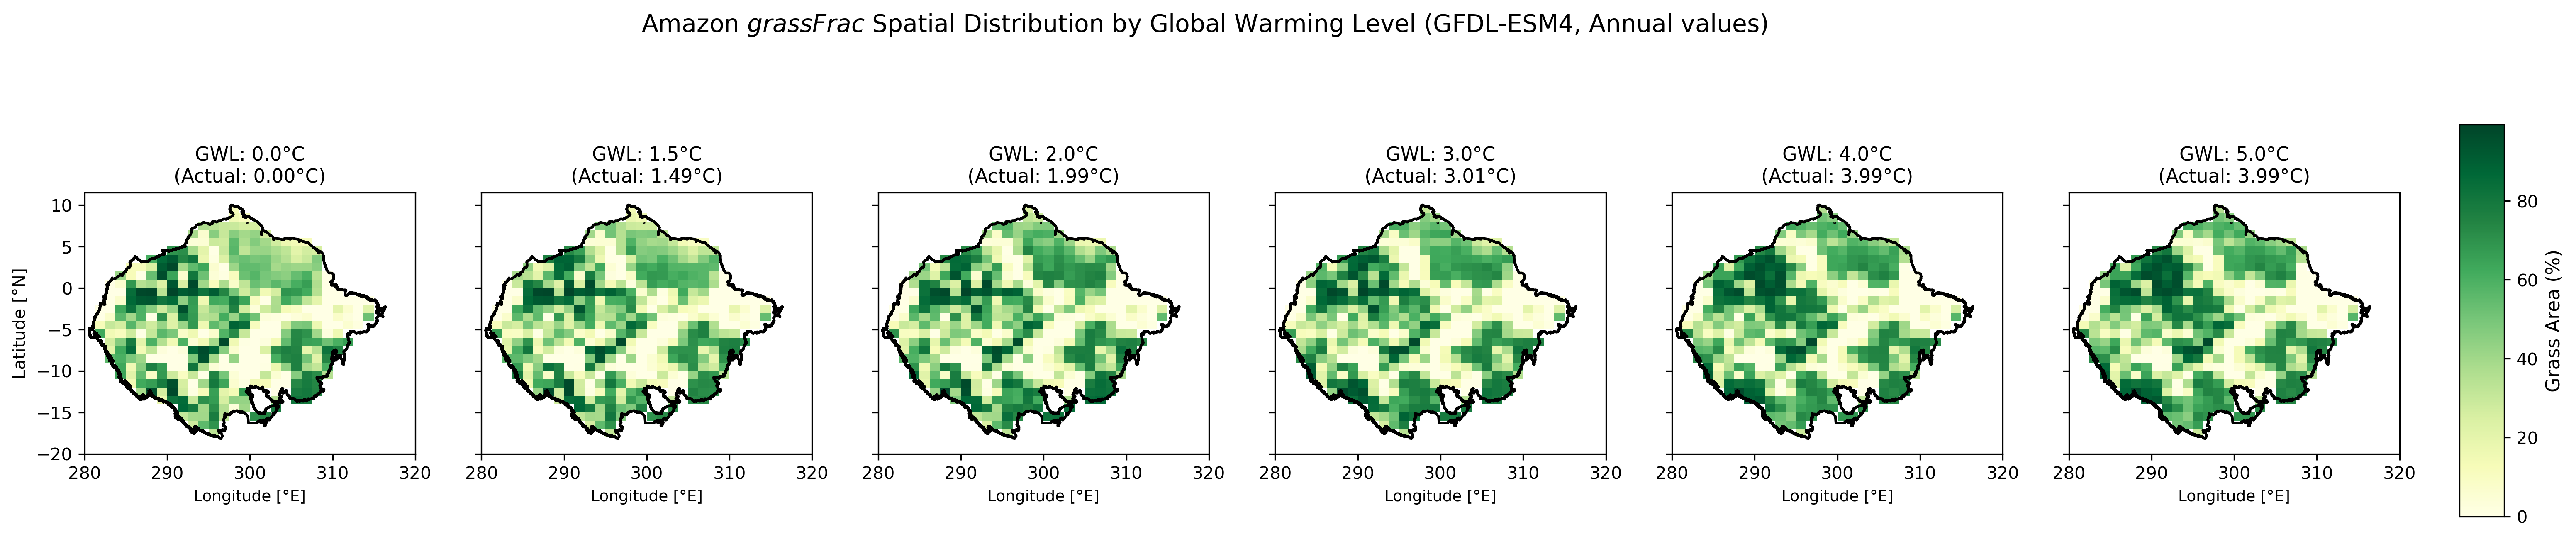

In [10]:
spatial_path = amazon_dir / f"plots/{MODEL}/SpatialMap_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(spatial_path)))

### 2. Start "Tipping and Other Abrupt events Detector" (TOAD) Python Package

In [11]:
import sys
import os

# Add Amazon directory to path (already done in prerequisites)
from toad import TOAD

td = TOAD(ds, time_dim="GWL")

### Step 1: Compute shifts


In [12]:
import sys
import os

# Add Amazon directory to path (already set up in prerequisites)
from custom_shift_method import ASDETECT

#alternatiave if you want to use the custom method uncomment the following line and comment the previous one
# from custom_shift_method import FilteredASDETECT  


# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

cveg_method = ASDETECT()

#If using the FilteredASDETECT method, you can set the parameters as follows:
# cveg_method = FilteredASDETECT(
  #  window_indices=15,       # 15 years before and after
   # min_abs_change=2.0,      # at least 2 kgC/m2 absolute change
    #min_rel_change=0.25      # at least 25% relative change)
# define variable and method
td.compute_shifts(var=VARIABLE, method=cveg_method)
# ~3m 15s

Shift detection (960 grid cells in 15 blocks):   0%|          | 0/15 [00:00<?, ?it/s]

INFO: New shifts variable grassFrac_dts: min/mean/max=-1.000/0.021/0.989 using 452 grid cells. Skipped 52.9% grid cells: 508 NaN, 0 constant.


### 2.1.1 Show All Detected Abrupt Shifts

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Maximum shift magnitude for grassFrac'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

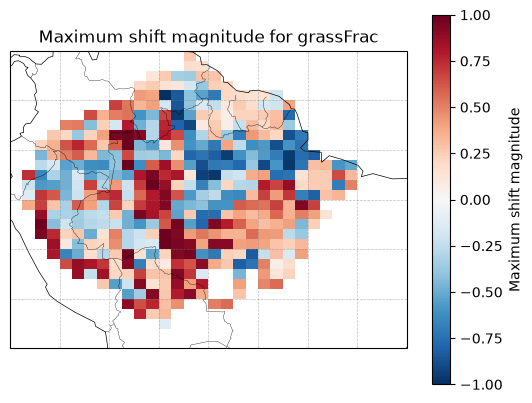

In [13]:
td.plot.max_shift_map()

##### Show shifts satisfying `shift_magnitude_threshold` and `shift_direction`

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for grassFrac'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

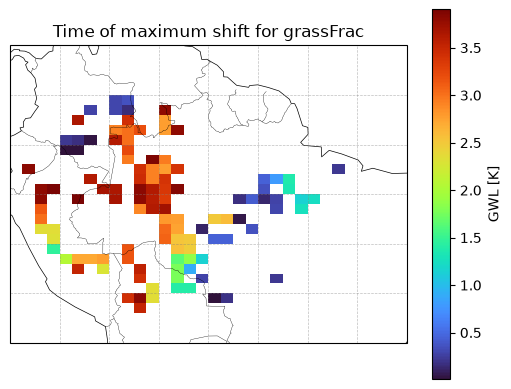

In [24]:
td.plot.time_of_max_shift_map(shift_direction="positive", shift_threshold=0.5)
# where abs(shift) > shift_threshold.

#### Check the Single Grid - Detected Series

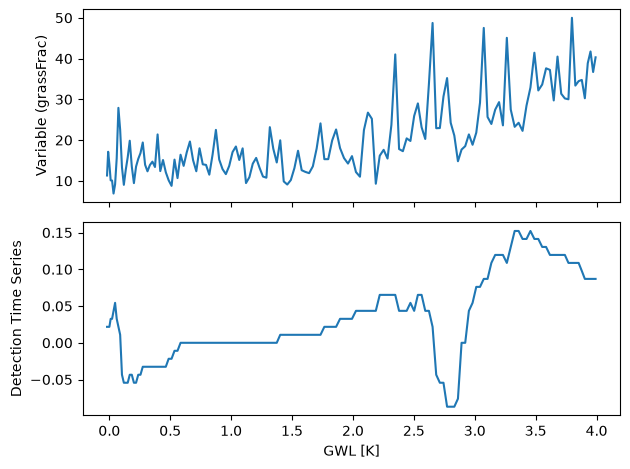

In [25]:
fig, axs = plt.subplots(2, sharex=True)
target_lon = 305.0  # e.g., 300°E
target_lat = 5.0   # e.g., 5°S

td.data[VARIABLE].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[0])
td.data[f"{VARIABLE}_dts"].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[1])

axs[0].set_ylabel(f"Variable ({VARIABLE})")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

### 2.2 Basic Clustering (not optmized)

Basically, all clustering apply filter : `DEFAULT_SHIFT_THRESHOLD`: float = 0.5.

This means, the clustering will only filter detected shifts whose absolute magnitude are larger than 0.5

In [29]:
from toad.clustering.methods.space_time_dbscan import SpaceTimeDBSCAN
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    method=SpaceTimeDBSCAN(
        spatial_eps=2000,  # km 
        temporal_eps=0.3,  # units of the time variable -> our time steps is 'GWL" degree 
        min_samples=10 # 15~55
    ),
    shift_direction='positive' # This filter only "decreasing" abrupt shift.
)

INFO: New cluster variable grassFrac_dts_cluster: Identified 2 clusters in 123 pts; Left 13.0% as noise (16 pts).


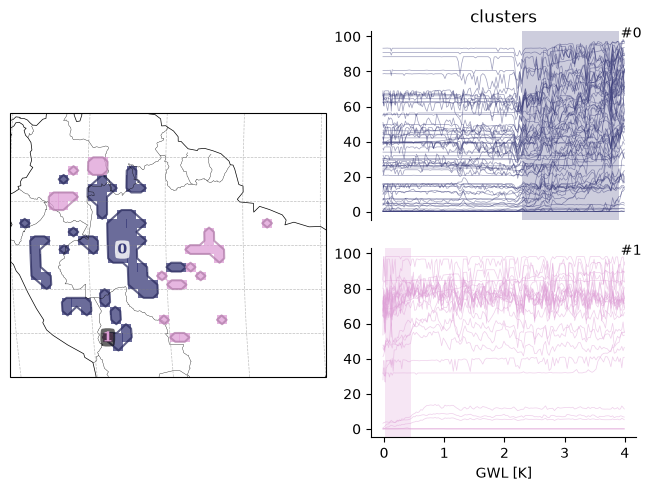

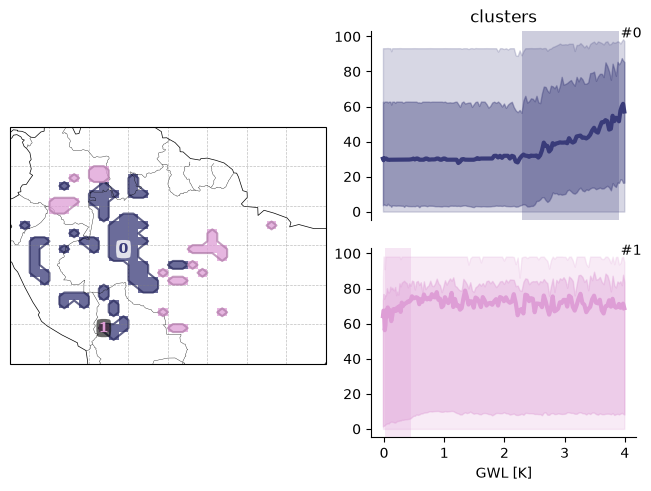

In [30]:
td.plot.overview(map_style={"projection": "global"});
td.plot.overview(mode="aggregated");

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
#from matplotlib.cm import get_cmap
#for windows users, you may need to install the packages below. Comment out the equivalent from the lines above. 
import matplotlib as mpl
#from matplotlib import colormaps


def plot_3d_spatiotemporal_clusters(
    td,
    var="cVeg",
    shift_direction="negative",
    view_angle=(30, -60),
    shapefile_path=None,
):

    # ---------------------------------------------------
    # Extract TOAD results
    # ---------------------------------------------------

    transition_time = td.stats(var).time.compute_transition_time(
        shift_direction=shift_direction
    )

    clusters_3d = td.get_clusters(var)
    clusters_2d = clusters_3d.max(dim=td.time_dim)

    lons, lats = np.meshgrid(
        transition_time.lon.values,
        transition_time.lat.values,
    )

    gwl_vals = transition_time.values.flatten()
    lon_vals = lons.flatten()
    lat_vals = lats.flatten()
    cluster_vals = clusters_2d.values.flatten()

    # Convert longitude from 0–360 to -180–180
    lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    valid_mask = ~np.isnan(gwl_vals)

    gwl_valid = gwl_vals[valid_mask]
    lon_valid = lon_vals[valid_mask]
    lat_valid = lat_vals[valid_mask]
    cluster_valid = cluster_vals[valid_mask]

    # ---------------------------------------------------
    # Figure
    # ---------------------------------------------------

    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection="3d")

    #cmap = get_cmap("tab10")
    #for windows users, comment out the previous line and uncomment the line below. 
    cmap = mpl.colormaps['viridis']

    # ---------------------------------------------------
    # Determine floor height
    # ---------------------------------------------------

    z_floor = np.nanmin(gwl_valid) - 0.2

    # ---------------------------------------------------
    # Plot faint projection on floor
    # ---------------------------------------------------

    ax.scatter(
        lon_valid,
        lat_valid,
        np.full_like(gwl_valid, z_floor),
        c="lightgray",
        s=6,
        alpha=0.15,
        depthshade=False,
    )

    # ---------------------------------------------------
    # Noise
    # ---------------------------------------------------

    noise_mask = (cluster_valid == -1) | np.isnan(cluster_valid)

    ax.scatter(
        lon_valid[noise_mask],
        lat_valid[noise_mask],
        gwl_valid[noise_mask],
        c="gray",
        s=70,
        alpha=0.5,
        depthshade=False,
        label="Unclustered (Noise)",
    )

    # ---------------------------------------------------
    # Clusters
    # ---------------------------------------------------

    unique_clusters = np.unique(cluster_valid[~noise_mask])

    for i, cid in enumerate(unique_clusters):

        mask = cluster_valid == cid

        ax.scatter(
            lon_valid[mask],
            lat_valid[mask],
            gwl_valid[mask],
            color=cmap(i % 10),
            s=70,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.95,
            depthshade=False,
            label=f"Cluster #{int(cid)}",
        )

    # ---------------------------------------------------
    # Amazon boundary
    # ---------------------------------------------------

    if shapefile_path is not None:

        amazon = gpd.read_file(shapefile_path)

        if "bioma" in amazon.columns:
            amazon = amazon[amazon["bioma"] == "Amazonía"]

        for geom in amazon.geometry:

            polygons = [geom] if geom.geom_type == "Polygon" else geom.geoms

            for poly in polygons:

                x, y = poly.exterior.xy

                x = np.asarray(x)
                y = np.asarray(y)

                x = np.where(x > 180, x - 360, x)

                ax.plot(
                    x,
                    y,
                    zs=z_floor,
                    color="black",
                    linewidth=1.5,
                    alpha=0.8,
                )

    # ---------------------------------------------------
    # Axis settings
    # ---------------------------------------------------

    ax.set_xlim(-82, -45)
    ax.set_ylim(-20, 10)

    ax.set_zlim(
        np.nanmin(gwl_valid) - 0.2,
        np.nanmax(gwl_valid) + 0.2,
    )

    # Make the box visually balanced
    ax.set_box_aspect((1.35, 1.0, 1.1))

    ax.set_xlabel("Longitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_ylabel("Latitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_zlabel("Global Warming Level (°C)", fontsize=11, fontweight="bold", labelpad=12)

    ax.set_title(
        f"3D Spatiotemporal Clustering of {var} Abrupt Shifts",
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    ax.view_init(
        elev=view_angle[0],
        azim=view_angle[1],
    )

    # Light grid
    ax.grid(True, alpha=0.3)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Cluster Groups",
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

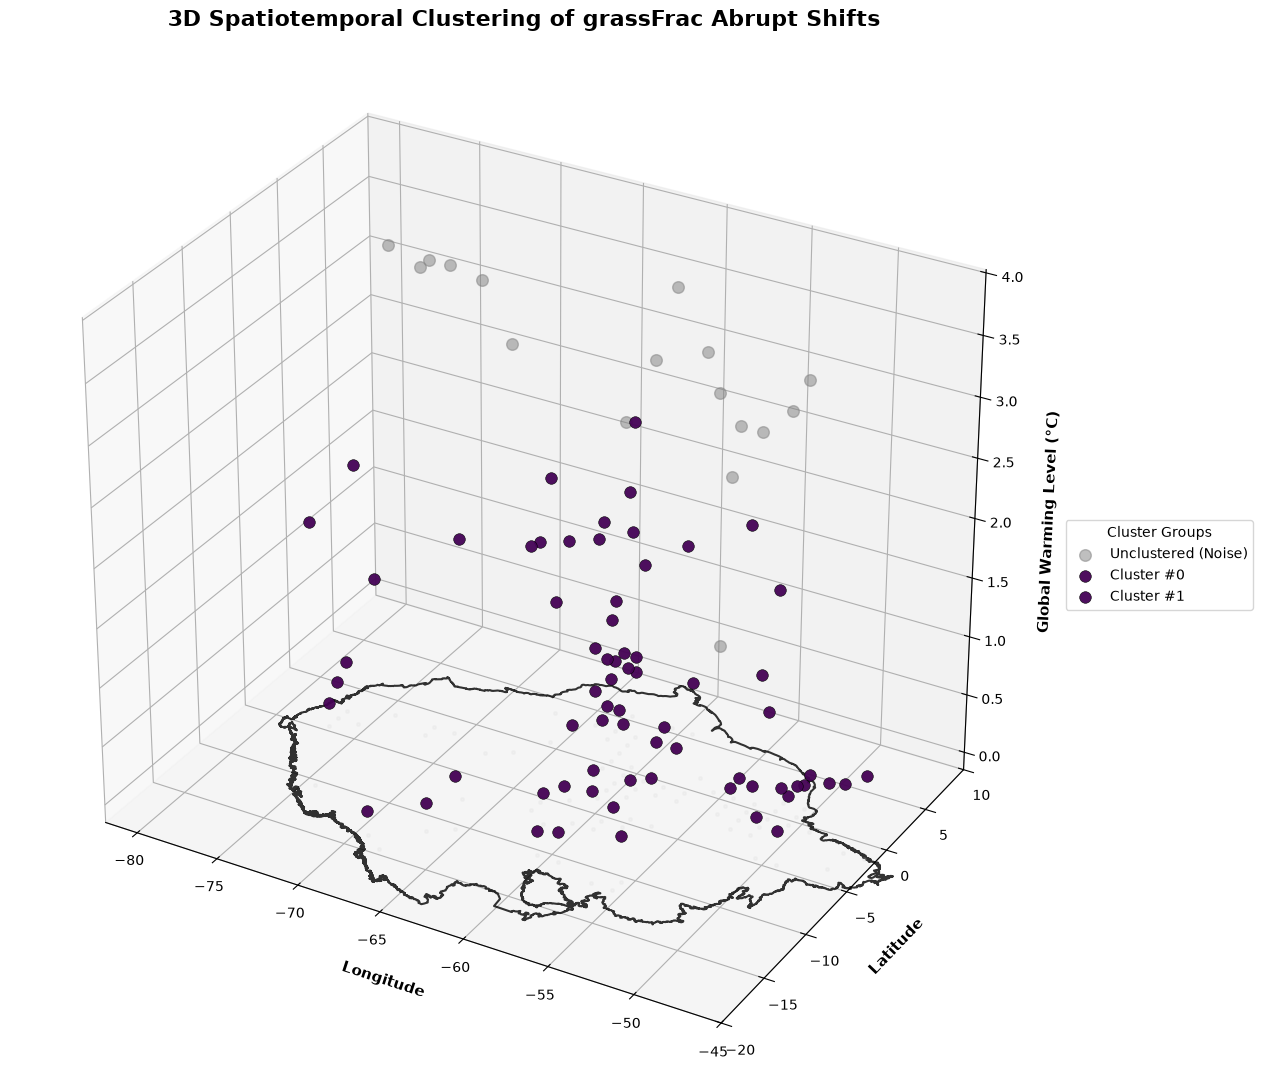

In [19]:
shapefile_path = amazon_dir.parent / "data/Biome/Biomas.shp"
plot_3d_spatiotemporal_clusters(td, var=VARIABLE, shapefile_path=str(shapefile_path))

### 2.3 Optimized Clustering with Parameter Range Setting

INFO: optimizing 1000 trials with params: {'spatial_eps': (200, 4500), 'temporal_eps': (0.1, 4.5), 'min_samples': (4, 50)}


  0%|          | 0/1000 [00:00<?, ?it/s]

INFO: Ran 1000 trials in 41.03 seconds. Best (#610): score 0.4446, params {'spatial_eps': 663, 'temporal_eps': 1.148770953298021, 'min_samples': 26}. 
INFO: New cluster variable grassFrac_dts_cluster: Identified 1 cluster in 103 pts; Left 72.8% as noise (75 pts).


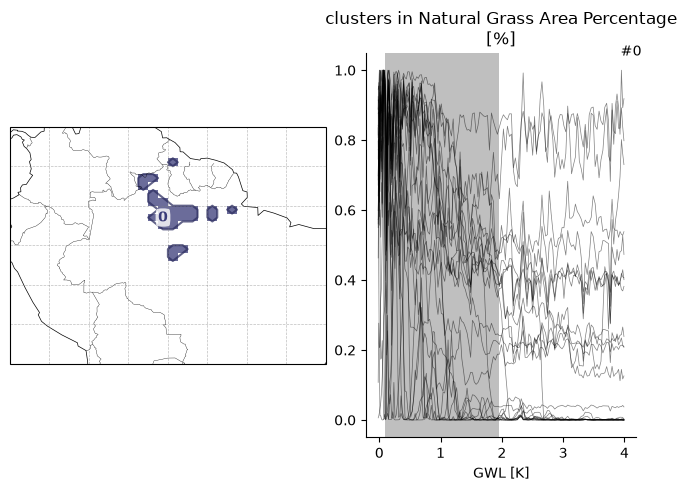

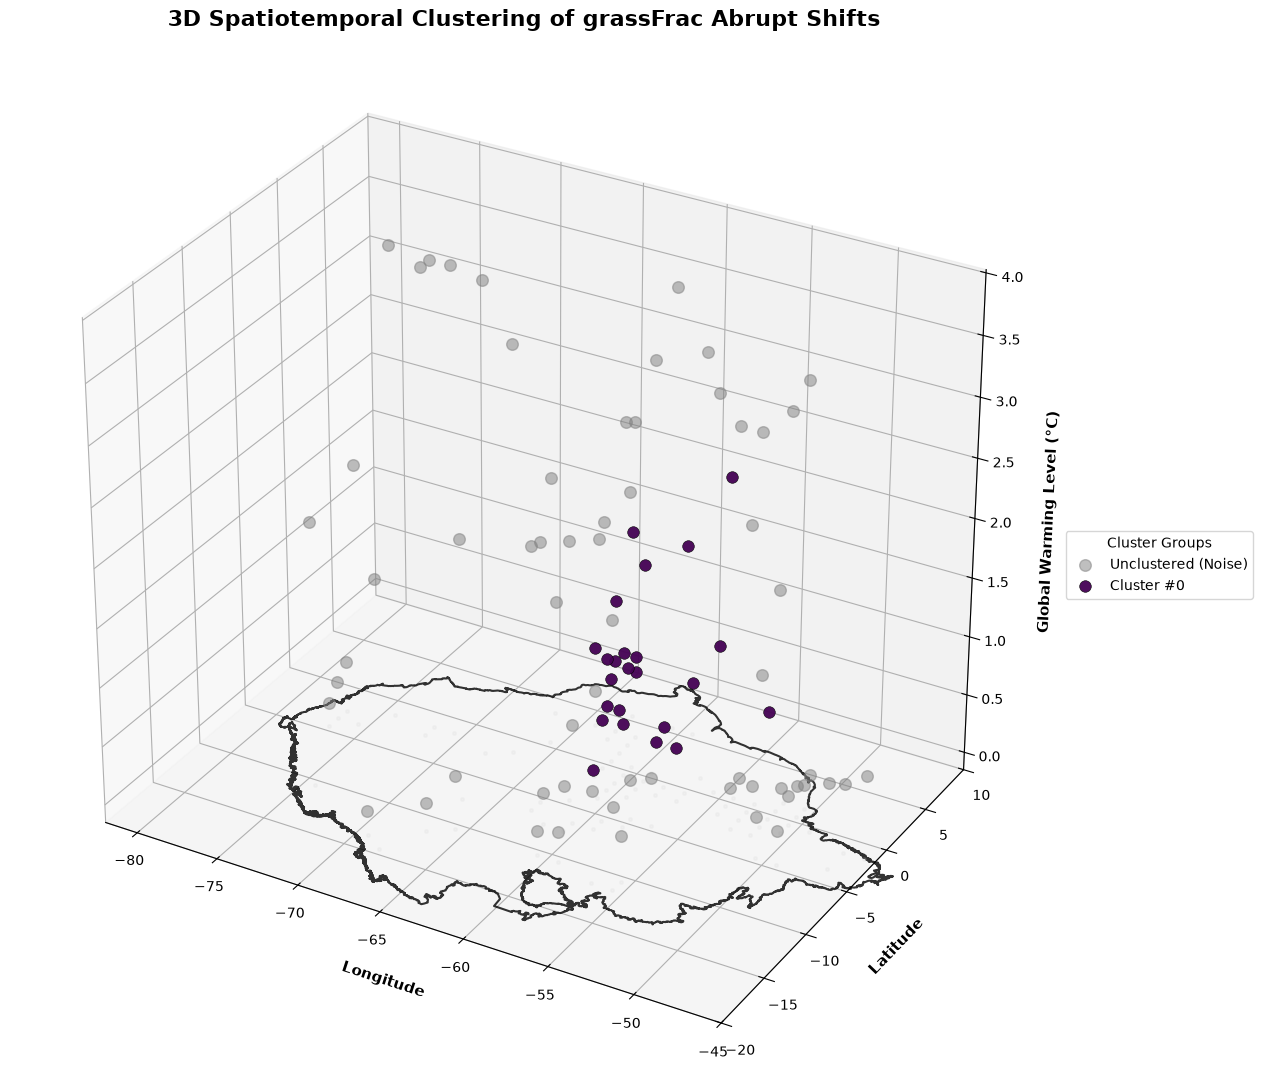

In [20]:
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    var=VARIABLE,
    method=SpaceTimeDBSCAN,
    shift_direction="negative",
    shift_selection="local",

    optimize=True,
    optimize_params={
        "spatial_eps": (200, 4500),   # provide a range in [km]
        "temporal_eps": (0.1, 4.5),       # update based on the GWL range of the model selected. Units are in [°C]
        "min_samples": (4, 50),            # integer. The lower bound is the minimum number of samples required to form a cluster, and the upper bound is the maximum number of samples allowed in a cluster. The range should be chosen based on the expected size of clusters in the data.
    },

    optimize_objective="combined_spatial_nonlinearity", #Select the method with which one would like to optimize the clustering parameters.
    optimize_direction="maximize",
    optimize_n_trials=1000, #set the number of trials for the optimization process. A higher number of trials may lead to better optimization results but will take longer to compute.
    overwrite=True,
)

# plot the latest cluster variable
td.plot.overview(td.cluster_vars[-1], normalize="max_each") #normalisation the y-axis 
#td.plot.overview(td.cluster_vars[-1])

#plot the 3D Spatiotemporal clusters with the shapefile of the Amazon biome and the optimized clustering parameters
shapefile_path = amazon_dir.parent / "data/Biome/Biomas.shp"
plot_3d_spatiotemporal_clusters(td, var=VARIABLE, shapefile_path=str(shapefile_path))

In [21]:
td

In [22]:
# You can find all method parameters used for the computation in the attributes, e.g:
getattr(td.data, f"{VARIABLE}_dts").attrs

{'long_name': 'Natural Grass Area Percentage',
 'units': '%',
 'cell_methods': 'area: mean where land over all_area_types time: mean',
 'cell_measures': 'area: areacella',
 'ocean_fillvalue': np.float32(0.0),
 'normalization_corrected': 'per-grid-cell-area',
 'standard_name': 'area_fraction',
 'interp_method': 'conserve_order1',
 'original_name': 'grassFrac',
 'unit_conversion': 'none',
 'aggregation': 'mean',
 'time_dim': 'GWL',
 'method_name': 'ASDETECT',
 'toad_version': '1.0.8',
 'base_variable': 'grassFrac',
 'variable_type': 'shift',
 'shifts_ignore_nan_warnings': 'False',
 'shifts_lmin': '5',
 'shifts_segmentation': 'two_sided'}

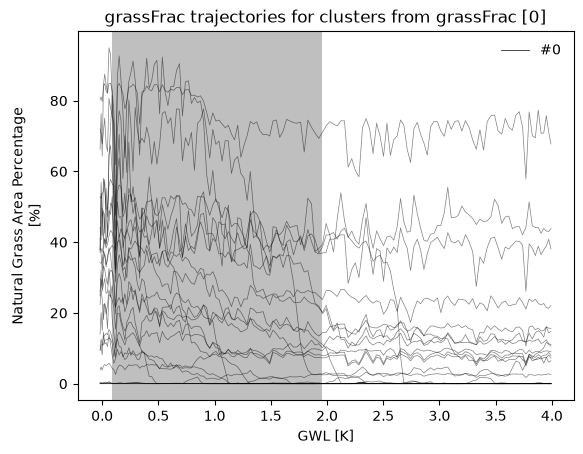

In [23]:
#Plot the time series of the clusters, you can specify which clusters to plot by providing a list of cluster IDs. If no cluster IDs are provided, all clusters will be plotted.
td.plot.timeseries(cluster_ids=[0]); 